In [1]:
%load_ext autoreload
%autoreload 2
from statsmodels.regression.linear_model import OLS
import statsmodels.api as sm
from DCC_class import *
from Utilities import *
import matplotlib.pyplot as plt

Let's use S&P 500 and US 5 year Treasury yield as an example. Typically, using interest rate to forecast equity is poor. Intuitively, since rates go down during a normal recession, and go up during a stagflationary scenario. However, in both cases, equities can go down. This means that the correlation of IR and EQ can be positive and negative from time to time. Thus, on average the unconditional correlation is very low between IR and EQ. This is a perfect example of using Dynamic Conditional Correlation to separate positive and negative correlations during different market regimes

In [9]:
spx = pd.read_csv('Data/SPX.csv')
spx1 = pd.read_csv('Data/SPX1.csv')
spx['Date'] = pd.to_datetime(spx['Date'])
spx1['Date'] = pd.to_datetime(spx1['Date'])
spx = pd.concat([spx, spx1])
spx = spx.set_index('Date')
spx['Price'] = spx['Price'].str.replace(',', '', regex=True)
spx['Price'] = spx['Price'].astype(float)
spx = spx[['Price']]
spx = spx[::-1]
spx.columns = ['SPX']

ust = pd.read_excel('Data/DGS10.xlsx', sheet_name='Daily')
ust.columns = ['Date', 'UST']
ust = ust.set_index('Date')
ust.index = pd.to_datetime(ust.index)

data = pd.concat([spx, ust], axis=1)
data = data.dropna()
data = data.resample('ME').last()
data['SPX'] = np.log(data['SPX']).diff() * 100
data['UST'] = data['UST'].diff() * 100
data = data.dropna()

/var/folders/y9/x00dm25d5g7_3bmgmz2c8bh00000gn/T/ipykernel_7138/1957367157.py:4: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  spx1['Date'] = pd.to_datetime(spx1['Date'])


The unconditional correlation between US 10Y Treasury Yield and S&P 500 is quite low and fitting a linear regression will only produce an adjusted R squared of 0.02, very poor fit

In [3]:
print(f'Correlation: {np.corrcoef(data['SPX'], data['UST'])[1][0]}')
reg = OLS(data['SPX'], sm.add_constant(data['UST'])).fit()
print(reg.summary())

Correlation: 0.15883709714645808
                            OLS Regression Results                            
Dep. Variable:                    SPX   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     7.998
Date:                Mon, 02 Mar 2026   Prob (F-statistic):            0.00499
Time:                        20:12:22   Log-Likelihood:                -897.99
No. Observations:                 311   AIC:                             1800.
Df Residuals:                     309   BIC:                             1807.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.53

This is because the correlation, just like volatility, is time-varying. We now fit a dynamic conditional correlation model. Recall that for DCC, the return vector is assumed to follow
$R_t \sim [M_t, \Sigma_t]$, let the standardised residuals be defined as
$$ \nu_t = D_t^{-1}(r_t - M_t)$$
where $D_t$ is a diagonal matrix with $D_{t, ii} =d_{t, i}$ and $D_t{i,j} = 0$. $d_{t, i}$ is the volatility of asset i, which can be estimated by univariate GARCH model. Define
$$\bar{R} = 1/T\sum_{t=1}^{T}\nu_t \nu_t^T$$. Then the conditional correlation matrix at time t is given by
$$ Q_t = \bar{R} + A(Q_{t-1} - \bar{R}) + B(\nu_t \nu_t^T - \bar{R})$$



In [4]:
dcc = DCC(data, vol_asymmetry=True).fit()
print(dcc.summary())

Optimization terminated successfully.
         Current function value: 7.364082
         Iterations: 32
         Function evaluations: 59
                                 DCC Results                                  
Dep. Variable:         ['SPX', 'UST']   Log-Likelihood:                -2290.2
Model:                            DCC   AIC:                             4588.
Method:            Maximum Likelihood   BIC:                             4603.
Date:                Mon, 02 Mar 2026                                         
Time:                        20:13:19                                         
No. Observations:                 311                                         
Df Residuals:                     309                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------

Plotting the estimated conditional correlation with the unconditional correlation being the horizontal line

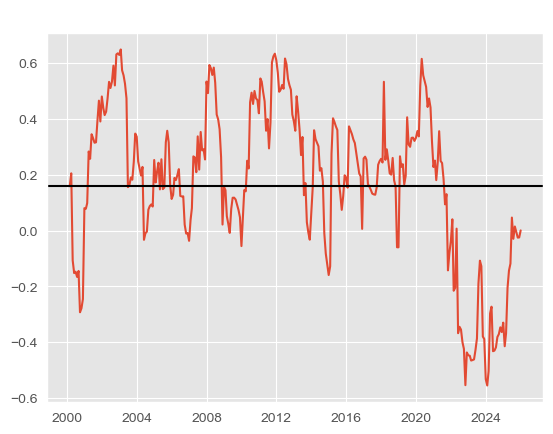

In [6]:
conditional_corr = dcc.conditional_cov()['Conditional correlation']
corr = []
for i in range(len(conditional_corr)):
    corr.append(conditional_corr[i][1, 0])

corr = pd.DataFrame(corr)
corr.index = data.index

plt.plot(corr)
plt.style.use('ggplot')
plt.axhline(np.corrcoef(data.T)[1][0], color='k')
plt.title('Correlation correlation')
plt.show()

Note how the correlation peaks during stress period and stay under during calm period. It even switches signs in the past years due to the rising inflation. Intuitively, positive and negative correlations cancel out which makes the unconditional correlation so low that linear regression does not work. This is how we can utilize the time-varying correlation to generate different scenario for stress testing purposes. Say we want to recreate a 2008 financial crisis but with a different realization of S&P 500. Similar to a regression, we can use the covariance matrix estimated during 2008, then pass a value for S&P 500 and ask what is the conditional mean of US 10Y Treasury Yield given S&P 500 during 2008. This can be done by utilizing the multivariate Normal or Student's T property. Specifically, let $X_1$ be the vector of variables we are interested and $X_2$ be the input variables. If $X_1, X_2$ are jointly Normal or Student's T, that is
$$\begin{bmatrix}
 \mathbf{x}_1 \\
 \mathbf{x}_2
\end{bmatrix} \sim \begin{bmatrix}
\begin{bmatrix}
 \boldsymbol\mu_1 \\
 \boldsymbol\mu_2
\end{bmatrix}, \begin{bmatrix}
 \boldsymbol\Sigma_{11} & \boldsymbol\Sigma_{12} \\
 \boldsymbol\Sigma_{21} & \boldsymbol\Sigma_{22}
\end{bmatrix} \end{bmatrix} $$

Then
$$\mathbf{E}[X_1 | \mathbf{x}_2 = a]
=
\boldsymbol\mu_1 + \boldsymbol\Sigma_{12} \boldsymbol\Sigma_{22}^{-1}
\left(
 \mathbf{a} - \boldsymbol\mu_2
\right)$$


In [7]:
# let's assume a 10% drop in S&P 500 and find out the maximum response US 10Y Treasury Yield could be during 2007-2009 financial crisis and during the late close to stagflation era
partial_views = [[-10]]
partial_names = ['SPX']
# We search for all the predictions using covariance matrices during 2007 - 2009 and report the maximum in terms of magnitude (this is for purpose of stress testing, not forecasting)
start = pd.to_datetime('07/10/31', format='%y/%m/%d')
end = pd.to_datetime('09/12/31', format='%y/%m/%d')
prediction_GFC = SPX_UST(data, partial_views, partial_names, **{'start': start, 'end': end, 'criterion': 'Min'})
prediction_GFC['output']

Optimization terminated successfully.
         Current function value: 7.394566
         Iterations: 35
         Function evaluations: 71


,UST
100,-42.212606


Now let's look how the US 10Y Treasury Yield would respond to a 10% drop in S&P in today's condition

In [8]:
# We now search for period form 2022 - 2025. Notice how by passing the same values for S&P, even the sign of US 10Y Treasury Yield changed in the prediction
start = pd.to_datetime('22/12/31', format='%y/%m/%d')
end = pd.to_datetime('25/12/31', format='%y/%m/%d')
prediction_rates_up = SPX_UST(data, partial_views, partial_names, **{'start': start, 'end': end, 'criterion': 'Max'})
prediction_rates_up['output']

Optimization terminated successfully.
         Current function value: 7.394566
         Iterations: 35
         Function evaluations: 71


,UST
287,36.24139


Notice the difference? Given the same expected loss of S&P, we have very different outcome for US 10Y Treasury Yield by utilizing the time-varying correlation matrix. -42 vs + 36 bps. By expanding into more assets, we can generate different scenarios for stress testing purposes.